# Fresh YOLO26s Forklift Detector Training

This notebook trains a **new forklift detector independently from the previously trained `best.pt`**.

The model is initialized from the generic Ultralytics pretrained checkpoint:

```text
yolo26s.pt
```

and fine-tuned using:

```text
data/
└── Forklift.v5-augmented-accurate_model.yolo26/
    ├── train/
    ├── valid/
    ├── test/
    └── data.yaml
```

## Why initialize from `yolo26s.pt` instead of random weights?

This is a fresh detector for this project because it does **not** use the previous forklift checkpoint. However, transfer learning from generic pretrained YOLO weights is substantially more appropriate than random initialization for a dataset of this size.

The source dataset is converted to a single detection class:

```text
0: forklift
```

All non-forklift annotations are removed, while images without forklifts are preserved as negative/background examples.

The final checkpoint is exported as:

```text
results/
└── forklift_fresh_model/
    └── best_fresh.pt
```

## 1. Install dependencies

In [1]:
%pip install -q -U ultralytics pyyaml

print("Dependencies installed successfully.")

Note: you may need to restart the kernel to use updated packages.
Dependencies installed successfully.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and experiment configuration

The defaults are intended for an NVIDIA RTX 3060.

The Roboflow V5 dataset is already augmented, so this notebook applies only moderate additional augmentation.

In [ ]:
from pathlib import Path
import json
import random
import shutil
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import torch
import yaml

import ultralytics
from ultralytics import YOLO


# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().resolve()

SOURCE_DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "Forklift.v5-augmented-accurate_model.yolo26"
)

SOURCE_DATA_YAML = SOURCE_DATASET_ROOT / "data.yaml"

PREPARED_DATASET_ROOT = (
    PROJECT_ROOT
    / "data"
    / "Forklift.v5.fresh_forklift_only"
)

PREPARED_DATA_YAML = PREPARED_DATASET_ROOT / "data.yaml"

TRAIN_RUN_ROOT = (
    PROJECT_ROOT
    / "results"
    / "forklift_fresh_training"
)

RUN_NAME = "yolo26s_fresh_v5"

EXPORT_DIR = (
    PROJECT_ROOT
    / "results"
    / "forklift_fresh_model"
)


# ---------------------------------------------------------------------
# Model initialization
# ---------------------------------------------------------------------
# IMPORTANT:
# This is the generic pretrained YOLO checkpoint.
# The previous project's best.pt is NOT used anywhere in this notebook.
BASE_MODEL = "yolo26s.pt"


# ---------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------
EPOCHS = 80
IMAGE_SIZE = 640
BATCH_SIZE = 8
PATIENCE = 15
WORKERS = 4
DEVICE = 0

CONFIDENCE_THRESHOLD = 0.25


# ---------------------------------------------------------------------
# Environment information
# ---------------------------------------------------------------------
print(f"Project root        : {PROJECT_ROOT}")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"Ultralytics version : {ultralytics.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU                 : {torch.cuda.get_device_name(DEVICE)}")
else:
    print(
        "\nWARNING: CUDA is unavailable. GPU training is strongly recommended."
    )

Project root        : C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2
Python version      : 3.12.13
PyTorch version     : 2.13.0+cu130
Ultralytics version : 8.4.116
CUDA available      : True
GPU                 : NVIDIA GeForce RTX 3060


## 3. Validate the source dataset

In [3]:
required_paths = {
    "Dataset root": SOURCE_DATASET_ROOT,
    "Dataset YAML": SOURCE_DATA_YAML,
}

missing_paths = []

for description, path in required_paths.items():
    exists = path.exists()
    print(f"{description:<15}: {path} | exists={exists}")

    if not exists:
        missing_paths.append((description, path))

if missing_paths:
    details = "\n".join(
        f"- {description}: {path}"
        for description, path in missing_paths
    )

    raise FileNotFoundError(
        "Required dataset files were not found:\n"
        f"{details}\n\n"
        "Run this notebook from the R2 project root or update Section 2."
    )

print("\nDataset path validation passed.")

Dataset root   : C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5-augmented-accurate_model.yolo26 | exists=True
Dataset YAML   : C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5-augmented-accurate_model.yolo26\data.yaml | exists=True

Dataset path validation passed.


## 4. Inspect source classes and identify `forklift`

No class ID is hard-coded. The notebook finds the class named exactly `forklift`, ignoring capitalization.

In [4]:
with open(SOURCE_DATA_YAML, "r", encoding="utf-8") as file:
    source_config = yaml.safe_load(file)

print("Source data.yaml")
print("-" * 80)
print(yaml.safe_dump(source_config, sort_keys=False, allow_unicode=True))


raw_names = source_config.get("names")

if isinstance(raw_names, dict):
    source_names = {
        int(class_id): str(class_name)
        for class_id, class_name in raw_names.items()
    }
elif isinstance(raw_names, list):
    source_names = {
        class_id: str(class_name)
        for class_id, class_name in enumerate(raw_names)
    }
else:
    raise ValueError("Invalid 'names' field in source data.yaml")


print("Source classes:")

for class_id, class_name in sorted(source_names.items()):
    print(f"  {class_id}: {class_name}")


forklift_matches = [
    class_id
    for class_id, class_name in source_names.items()
    if class_name.strip().casefold() == "forklift"
]

if len(forklift_matches) != 1:
    raise ValueError(
        "Expected exactly one class named 'forklift'. "
        f"Found matches: {forklift_matches}. "
        f"Available classes: {source_names}"
    )


SOURCE_FORKLIFT_CLASS_ID = forklift_matches[0]

print(f"\nForklift source class ID: {SOURCE_FORKLIFT_CLASS_ID}")

Source data.yaml
--------------------------------------------------------------------------------
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 2
names:
- forklift
- person
roboflow:
  workspace: mohamed-traore-2ekkp
  project: forklift-dsitv
  version: 5
  license: CC BY 4.0
  url: https://universe.roboflow.com/mohamed-traore-2ekkp/forklift-dsitv/dataset/5

Source classes:
  0: forklift
  1: person

Forklift source class ID: 0


## 5. Validate train / validation / test splits

In [5]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}


def list_images(directory: Path):
    return sorted(
        path
        for path in directory.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )


SOURCE_SPLITS = {
    "train": {
        "images": SOURCE_DATASET_ROOT / "train" / "images",
        "labels": SOURCE_DATASET_ROOT / "train" / "labels",
    },
    "valid": {
        "images": SOURCE_DATASET_ROOT / "valid" / "images",
        "labels": SOURCE_DATASET_ROOT / "valid" / "labels",
    },
    "test": {
        "images": SOURCE_DATASET_ROOT / "test" / "images",
        "labels": SOURCE_DATASET_ROOT / "test" / "labels",
    },
}


for split_name, split_paths in SOURCE_SPLITS.items():
    for path_type, path in split_paths.items():
        if not path.exists():
            raise FileNotFoundError(
                f"Missing {split_name}/{path_type}: {path}"
            )

    print(
        f"{split_name:<6} | "
        f"images={len(list_images(split_paths['images'])):>5} | "
        f"labels={len(list(split_paths['labels'].glob('*.txt'))):>5}"
    )

train  | images=  885 | labels=  885
valid  | images=   84 | labels=   84
test   | images=   42 | labels=   42


## 6. Create a forklift-only dataset

For every source image:

- forklift annotations are retained;
- forklift is remapped to class `0`;
- all other classes are removed;
- images with zero forklifts remain in the dataset with an empty label file.

The source Roboflow dataset is never modified.

In [6]:
def convert_label_file(
    source_label_path: Path,
    destination_label_path: Path,
    forklift_class_id: int,
) -> int:
    retained_annotations = []

    if source_label_path.exists():
        content = source_label_path.read_text(
            encoding="utf-8"
        ).strip()

        if content:
            for line_number, line in enumerate(
                content.splitlines(),
                start=1,
            ):
                fields = line.split()

                if len(fields) != 5:
                    raise ValueError(
                        f"Malformed YOLO annotation in {source_label_path}, "
                        f"line {line_number}: {line!r}"
                    )

                class_id = int(float(fields[0]))

                if class_id == forklift_class_id:
                    retained_annotations.append(
                        "0 " + " ".join(fields[1:])
                    )

    destination_label_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    destination_label_path.write_text(
        "\n".join(retained_annotations),
        encoding="utf-8",
    )

    return len(retained_annotations)


if PREPARED_DATASET_ROOT.exists():
    print(
        f"Removing existing prepared dataset: "
        f"{PREPARED_DATASET_ROOT}"
    )
    shutil.rmtree(PREPARED_DATASET_ROOT)


conversion_summary = {}


for split_name, source_paths in SOURCE_SPLITS.items():
    output_images_dir = (
        PREPARED_DATASET_ROOT
        / split_name
        / "images"
    )

    output_labels_dir = (
        PREPARED_DATASET_ROOT
        / split_name
        / "labels"
    )

    output_images_dir.mkdir(parents=True, exist_ok=True)
    output_labels_dir.mkdir(parents=True, exist_ok=True)

    source_images = list_images(source_paths["images"])

    positive_images = 0
    negative_images = 0
    forklift_boxes = 0

    for image_path in source_images:
        shutil.copy2(
            image_path,
            output_images_dir / image_path.name,
        )

        source_label_path = (
            source_paths["labels"]
            / f"{image_path.stem}.txt"
        )

        output_label_path = (
            output_labels_dir
            / f"{image_path.stem}.txt"
        )

        kept_boxes = convert_label_file(
            source_label_path,
            output_label_path,
            SOURCE_FORKLIFT_CLASS_ID,
        )

        forklift_boxes += kept_boxes

        if kept_boxes > 0:
            positive_images += 1
        else:
            negative_images += 1

    conversion_summary[split_name] = {
        "images": len(source_images),
        "positive_images": positive_images,
        "negative_images": negative_images,
        "forklift_boxes": forklift_boxes,
    }


print("Forklift-only conversion summary")
print("-" * 80)

for split_name, summary in conversion_summary.items():
    print(
        f"{split_name:<6} | "
        f"images={summary['images']:>5} | "
        f"positive={summary['positive_images']:>5} | "
        f"negative={summary['negative_images']:>5} | "
        f"forklift_boxes={summary['forklift_boxes']:>6}"
    )

Removing existing prepared dataset: C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only
Forklift-only conversion summary
--------------------------------------------------------------------------------
train  | images=  885 | positive=  876 | negative=    9 | forklift_boxes=   957
valid  | images=   84 | positive=   83 | negative=    1 | forklift_boxes=    96
test   | images=   42 | positive=   41 | negative=    1 | forklift_boxes=    43


## 7. Create the one-class YOLO dataset configuration

In [7]:
prepared_config = {
    "train": str(
        (
            PREPARED_DATASET_ROOT
            / "train"
            / "images"
        ).resolve()
    ),
    "val": str(
        (
            PREPARED_DATASET_ROOT
            / "valid"
            / "images"
        ).resolve()
    ),
    "test": str(
        (
            PREPARED_DATASET_ROOT
            / "test"
            / "images"
        ).resolve()
    ),
    "nc": 1,
    "names": ["forklift"],
}


with open(
    PREPARED_DATA_YAML,
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        prepared_config,
        file,
        sort_keys=False,
        allow_unicode=True,
    )


print(yaml.safe_dump(prepared_config, sort_keys=False, allow_unicode=True))
print(f"Saved to: {PREPARED_DATA_YAML}")

train: C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\train\images
val: C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\valid\images
test: C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\test\images
nc: 1
names:
- forklift

Saved to: C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\data.yaml


## 8. Audit the converted annotations

In [8]:
def audit_split(split_name: str):
    image_dir = (
        PREPARED_DATASET_ROOT
        / split_name
        / "images"
    )

    label_dir = (
        PREPARED_DATASET_ROOT
        / split_name
        / "labels"
    )

    missing_labels = []
    malformed_rows = []
    total_boxes = 0
    positive_images = 0
    negative_images = 0

    for image_path in list_images(image_dir):
        label_path = (
            label_dir
            / f"{image_path.stem}.txt"
        )

        if not label_path.exists():
            missing_labels.append(image_path.name)
            continue

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if not content:
            negative_images += 1
            continue

        positive_images += 1

        for line_number, line in enumerate(
            content.splitlines(),
            start=1,
        ):
            fields = line.split()

            if len(fields) != 5:
                malformed_rows.append(
                    (label_path.name, line_number, line)
                )
                continue

            try:
                class_id = int(float(fields[0]))
                x, y, width, height = map(float, fields[1:])
            except ValueError:
                malformed_rows.append(
                    (label_path.name, line_number, line)
                )
                continue

            valid = (
                class_id == 0
                and 0.0 <= x <= 1.0
                and 0.0 <= y <= 1.0
                and 0.0 < width <= 1.0
                and 0.0 < height <= 1.0
            )

            if valid:
                total_boxes += 1
            else:
                malformed_rows.append(
                    (label_path.name, line_number, line)
                )

    return {
        "split": split_name,
        "positive_images": positive_images,
        "negative_images": negative_images,
        "total_boxes": total_boxes,
        "missing_labels": missing_labels,
        "malformed_rows": malformed_rows,
    }


reports = [
    audit_split("train"),
    audit_split("valid"),
    audit_split("test"),
]


for report in reports:
    print("=" * 80)
    print(f"Split           : {report['split']}")
    print(f"Positive images : {report['positive_images']}")
    print(f"Negative images : {report['negative_images']}")
    print(f"Forklift boxes  : {report['total_boxes']}")
    print(f"Missing labels  : {len(report['missing_labels'])}")
    print(f"Malformed rows  : {len(report['malformed_rows'])}")


if any(
    report["missing_labels"] or report["malformed_rows"]
    for report in reports
):
    raise ValueError(
        "Prepared dataset validation failed."
    )


print("\nDataset audit passed.")

Split           : train
Positive images : 876
Negative images : 9
Forklift boxes  : 957
Missing labels  : 0
Malformed rows  : 0
Split           : valid
Positive images : 83
Negative images : 1
Forklift boxes  : 96
Missing labels  : 0
Malformed rows  : 0
Split           : test
Positive images : 41
Negative images : 1
Forklift boxes  : 43
Missing labels  : 0
Malformed rows  : 0

Dataset audit passed.


## 9. Visualize prepared ground-truth annotations

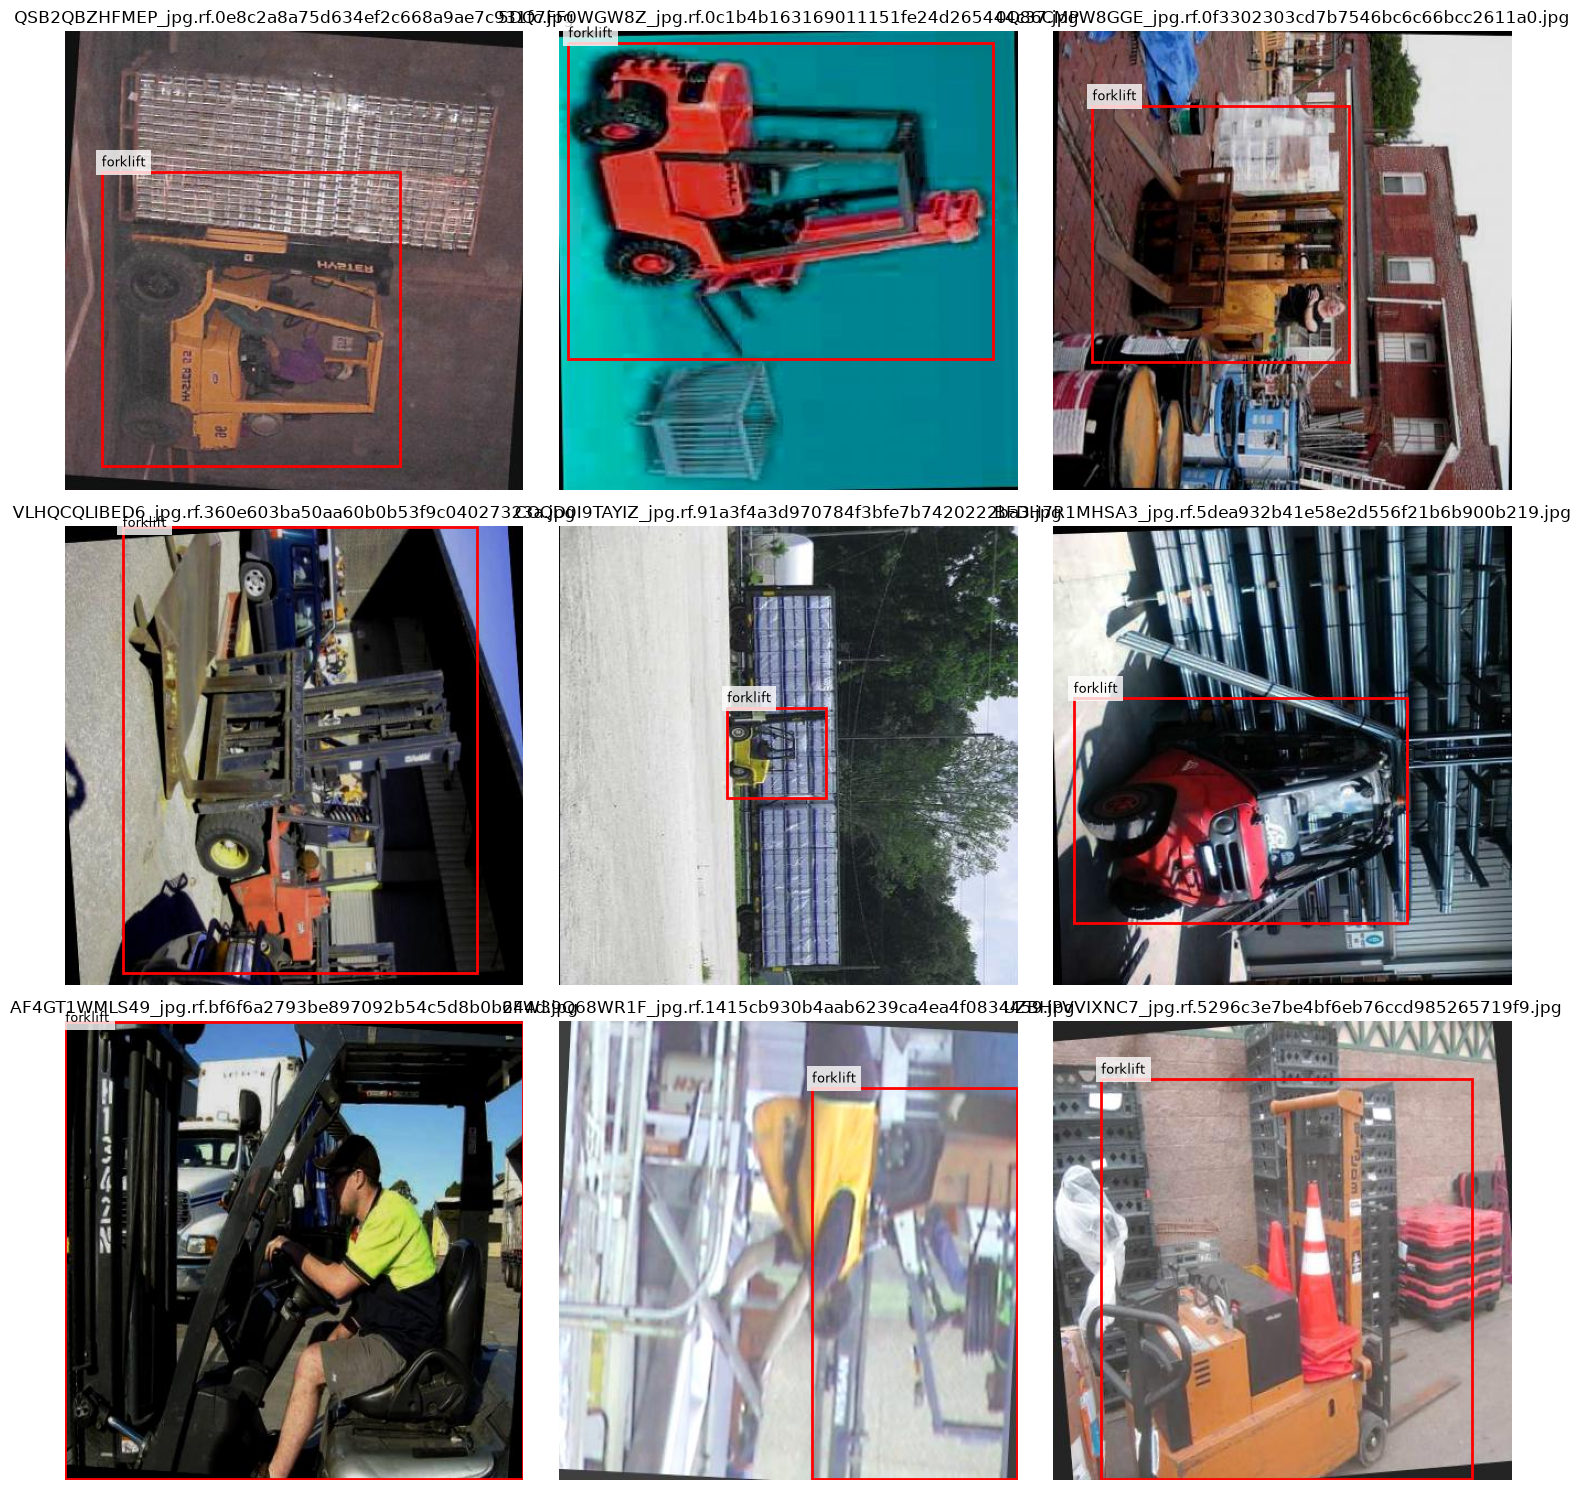

In [9]:
def read_yolo_boxes(label_path: Path):
    boxes = []

    if not label_path.exists():
        return boxes

    content = label_path.read_text(
        encoding="utf-8"
    ).strip()

    if not content:
        return boxes

    for line in content.splitlines():
        class_id, x, y, width, height = line.split()

        boxes.append(
            (
                int(float(class_id)),
                float(x),
                float(y),
                float(width),
                float(height),
            )
        )

    return boxes


train_images = list_images(
    PREPARED_DATASET_ROOT
    / "train"
    / "images"
)

selected_images = random.Random(SEED).sample(
    train_images,
    k=min(9, len(train_images)),
)


fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 15),
)

axes = np.atleast_1d(axes).reshape(-1)

for axis in axes:
    axis.axis("off")


for axis, image_path in zip(axes, selected_images):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    axis.imshow(image)

    label_path = (
        PREPARED_DATASET_ROOT
        / "train"
        / "labels"
        / f"{image_path.stem}.txt"
    )

    for _, xc, yc, bw, bh in read_yolo_boxes(label_path):
        x_min = (xc - bw / 2.0) * width
        y_min = (yc - bh / 2.0) * height

        rectangle = patches.Rectangle(
            (x_min, y_min),
            bw * width,
            bh * height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )

        axis.add_patch(rectangle)

        axis.text(
            x_min,
            max(0, y_min - 5),
            "forklift",
            fontsize=9,
            bbox={
                "facecolor": "white",
                "alpha": 0.8,
                "edgecolor": "none",
            },
        )

    axis.set_title(image_path.name)


plt.tight_layout()
plt.show()

## 10. Initialize a new YOLO26s detector

This is the critical distinction from the previous notebook:

```python
YOLO("yolo26s.pt")
```

is used here.

The old project checkpoint:

```text
results/forklift_yolo26s_artifacts/best.pt
```

is never loaded.

In [10]:
fresh_model = YOLO(BASE_MODEL)

print("Fresh detector initialized from:")
print(BASE_MODEL)

print("\nGeneric pretrained classes:")
print(fresh_model.names)

Fresh detector initialized from:
yolo26s.pt

Generic pretrained classes:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop',

## 11. Train the fresh detector

### Baseline configuration

| Parameter | Value |
|---|---:|
| Initialization | `yolo26s.pt` |
| Target classes | forklift only |
| Epochs | 80 |
| Image size | 640 |
| Batch size | 8 |
| Early stopping patience | 15 |
| Optimizer | Auto |
| Device | CUDA |

Because the source V5 dataset has already undergone offline augmentation, the additional online augmentations are intentionally moderate.

In [11]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. Enable the RTX 3060 before training."
    )


print("Starting fresh YOLO26s training")
print("-" * 80)
print(f"Initialization : {BASE_MODEL}")
print(f"Dataset        : {PREPARED_DATA_YAML}")
print(f"Epochs         : {EPOCHS}")
print(f"Image size     : {IMAGE_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"GPU            : {torch.cuda.get_device_name(DEVICE)}")


model = YOLO(BASE_MODEL)


training_results = model.train(
    data=str(PREPARED_DATA_YAML),

    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    patience=PATIENCE,

    optimizer="auto",
    cos_lr=True,

    degrees=3.0,
    translate=0.05,
    scale=0.15,
    fliplr=0.5,
    flipud=0.0,
    mosaic=0.2,
    close_mosaic=10,

    seed=SEED,
    deterministic=True,

    project=str(TRAIN_RUN_ROOT),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    verbose=True,
)


RUN_DIR = TRAIN_RUN_ROOT / RUN_NAME

BEST_MODEL_SOURCE = (
    RUN_DIR
    / "weights"
    / "best.pt"
)

LAST_MODEL_SOURCE = (
    RUN_DIR
    / "weights"
    / "last.pt"
)


if not BEST_MODEL_SOURCE.exists():
    raise FileNotFoundError(
        f"Training finished but best.pt was not found: "
        f"{BEST_MODEL_SOURCE}"
    )


print("\nFresh model training completed successfully.")
print(f"Run directory : {RUN_DIR}")
print(f"Best model    : {BEST_MODEL_SOURCE}")
print(f"Last model    : {LAST_MODEL_SOURCE}")

Starting fresh YOLO26s training
--------------------------------------------------------------------------------
Initialization : yolo26s.pt
Dataset        : C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\data.yaml
Epochs         : 80
Image size     : 1280
Batch size     : 2
GPU            : NVIDIA GeForce RTX 3060
Ultralytics 8.4.116  Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\data.yaml, degrees=3.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5,

## 12. Evaluate on the held-out test split

In [12]:
validation_model = YOLO(str(BEST_MODEL_SOURCE))


test_metrics = validation_model.val(
    data=str(PREPARED_DATA_YAML),
    split="test",
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
    project=str(TRAIN_RUN_ROOT),
    name=f"{RUN_NAME}_test",
    exist_ok=True,
)


results_dictionary = getattr(
    test_metrics,
    "results_dict",
    {},
)


print("Test-set metrics")
print("-" * 80)

for metric_name, metric_value in results_dictionary.items():
    try:
        print(
            f"{metric_name:<40}: "
            f"{float(metric_value):.6f}"
        )
    except (TypeError, ValueError):
        print(
            f"{metric_name:<40}: "
            f"{metric_value}"
        )


box_metrics = getattr(test_metrics, "box", None)

if box_metrics is not None:
    print("\nSummary")
    print("-" * 80)
    print(f"mAP50-95 : {float(box_metrics.map):.6f}")
    print(f"mAP50    : {float(box_metrics.map50):.6f}")
    print(f"mAP75    : {float(box_metrics.map75):.6f}")

Ultralytics 8.4.116  Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 12288MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.8 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 3.71.3 MB/s, size: 35.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\test\labels... 42 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 42/42 641.5it/s 0.1s
val: New cache created: C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\data\Forklift.v5.fresh_forklift_only\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.5it/s 4.6s<0.1s
                   all         42         43      0.482      0.419      0.314    

## 13. Qualitative predictions on test images

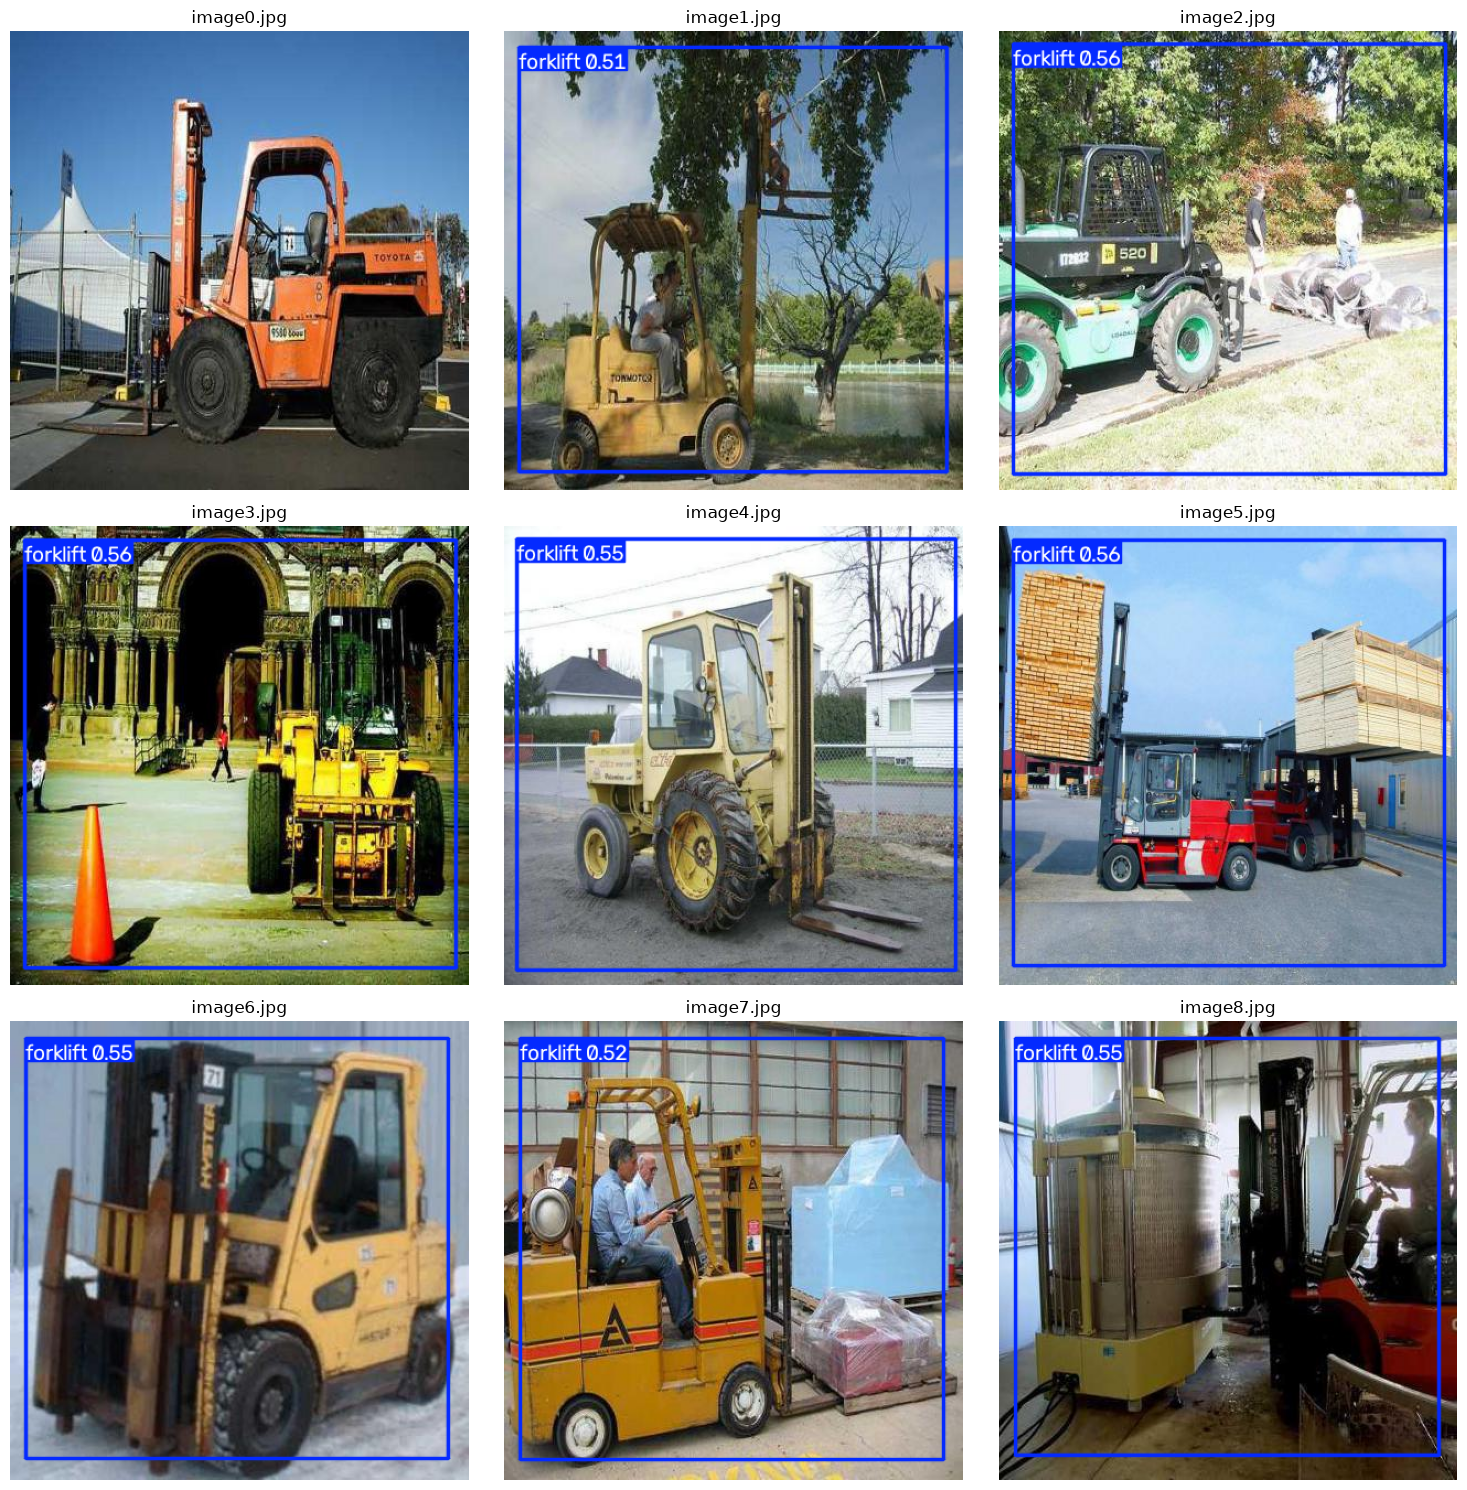

In [13]:
test_images = list_images(
    PREPARED_DATASET_ROOT
    / "test"
    / "images"
)

selected_test_images = random.Random(SEED).sample(
    test_images,
    k=min(9, len(test_images)),
)


# Use a fresh model after validation. With PyTorch 2.13, Ultralytics
# validation leaves its model instance backed by inference tensors.
prediction_model = YOLO(str(BEST_MODEL_SOURCE))


predictions = prediction_model.predict(
    source=[str(path) for path in selected_test_images],
    conf=CONFIDENCE_THRESHOLD,
    imgsz=IMAGE_SIZE,
    device=DEVICE,
    quantize=16,  # FP16; replaces deprecated half=True in Ultralytics 8.4+
    verbose=False,
)


fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 15),
)

axes = np.atleast_1d(axes).reshape(-1)

for axis in axes:
    axis.axis("off")


for axis, result in zip(axes, predictions):
    rendered_rgb = result.plot()[..., ::-1]

    axis.imshow(rendered_rgb)
    axis.set_title(Path(result.path).name)


plt.tight_layout()
plt.show()

## 14. Export the fresh detector as `best_fresh.pt`

The exported directory is:

```text
results/
└── forklift_fresh_model/
    ├── best_fresh.pt
    ├── last_fresh.pt
    ├── results.csv
    ├── results.png
    └── experiment_summary.json
```

In [14]:
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FINAL_MODEL_PATH = (
    EXPORT_DIR
    / "best_fresh.pt"
)


shutil.copy2(
    BEST_MODEL_SOURCE,
    FINAL_MODEL_PATH,
)


if LAST_MODEL_SOURCE.exists():
    shutil.copy2(
        LAST_MODEL_SOURCE,
        EXPORT_DIR / "last_fresh.pt",
    )


for pattern in [
    "args.yaml",
    "results.csv",
    "results.png",
    "confusion_matrix*.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
]:
    for source_path in RUN_DIR.glob(pattern):
        if source_path.is_file():
            shutil.copy2(
                source_path,
                EXPORT_DIR / source_path.name,
            )


experiment_summary = {
    "initialization": BASE_MODEL,
    "previous_best_pt_used": False,
    "new_checkpoint": str(FINAL_MODEL_PATH),
    "source_dataset": str(SOURCE_DATASET_ROOT),
    "prepared_dataset": str(PREPARED_DATASET_ROOT),
    "classes": ["forklift"],
    "training": {
        "epochs_requested": EPOCHS,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "patience": PATIENCE,
        "optimizer": "auto",
        "seed": SEED,
    },
    "test_metrics": {},
}


for metric_name, metric_value in results_dictionary.items():
    try:
        experiment_summary["test_metrics"][metric_name] = float(
            metric_value
        )
    except (TypeError, ValueError):
        experiment_summary["test_metrics"][metric_name] = str(
            metric_value
        )


with open(
    EXPORT_DIR / "experiment_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_summary,
        file,
        indent=2,
        ensure_ascii=False,
    )


print("=" * 80)
print("EXPORT COMPLETED")
print("=" * 80)
print(f"Fresh model : {FINAL_MODEL_PATH}")
print(f"Artifacts   : {EXPORT_DIR}")

EXPORT COMPLETED
Fresh model : C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\results\forklift_fresh_model\best_fresh.pt
Artifacts   : C:\Users\Admin\Documents\2. Work\Data-Impact\warehouse-forklift-detection\r2\results\forklift_fresh_model


## 15. External Blind Corner Evaluation

After training, use:

```text
results/forklift_fresh_model/best_fresh.pt
```

in the existing tracking script.

Recommended initial inference configuration:

```python
CONF_THRESHOLD = 0.10
IOU_THRESHOLD = 0.5
IMAGE_SIZE = 1280
DEVICE = 0
```

Compare this model directly against the previous models on the same untouched Blind Corner video.

The most useful comparison is not only test-set mAP, but also:

- forklift detection continuity across consecutive frames,
- confidence on small/distant forklifts,
- false positives on pallets and racks,
- ByteTrack ID stability.